# Multi-Agent Deep AI Finance Researcher from scratch
**Multi-Agent System** with:
- One Orchestrator
- Two Researchers
- One Editor

### Setup

In [1]:
import sys
sys.path.append("D:/Cursos/Agentes/financial_deep_research_agent")

In [2]:
import os

In [3]:
from dotenv import load_dotenv
load_dotenv()

from agent.rag_tools import hybrid_search, live_finance_researcher

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langchain.messages import HumanMessage, AIMessage, ToolMessage

d:\Cursos\Agentes\financial_deep_research_agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-25 06:01:52.608 | WARNING  | fastembed.common.model_management:download_files_from_huggingface:223 - Local file sizes do not match the metadata.


In [4]:
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.types import Command


In [ ]:
from agent.file_state import ( DeepAgentState, ls, read_file, write_file, cleanup_files, generate_hash, _disk_path )

from agent.prompts import (
    ORCHESTRATOR_PROMPT,
    RESEARCHER_PROMPT,
    EDITOR_PROMPT
)

### Initialize components and create worke agents

In [6]:
model_orch = "gemini-3-flash-preview"
model_worker = "gemini-2.5-flash"
llm_orch = ChatGoogleGenerativeAI(model=model_orch, temperature=0.1)
llm_worker = ChatGoogleGenerativeAI(model=model_worker, temperature=0.1)

In [ ]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

conn = sqlite3.connect("D:/Cursos/Agentes/financial_deep_research_agent/data/sqlite/financial_research_agent.db", check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

In [8]:
#Researcher Agent
researcher_agent = create_agent(
    model=llm_worker,
    tools= [ls, write_file, read_file, hybrid_search, live_finance_researcher],
    system_prompt=RESEARCHER_PROMPT,
    state_schema=DeepAgentState,
)

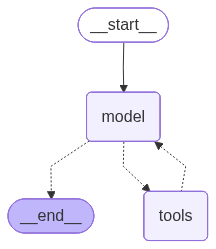

In [9]:
# "Editor Agent"
editor_agent = create_agent(
    model=llm_worker,
    tools= [ls, read_file, write_file, cleanup_files],
    system_prompt=EDITOR_PROMPT,
    state_schema=DeepAgentState,
)
editor_agent

### Defien Orchestrator Tools

In [10]:
from typing import Annotated

In [ ]:
@tool 
def write_research_plan(thematic_questions: list[str], state: Annotated[DeepAgentState, InjectedState], tool_call_id: Annotated[str, InjectedToolCallId]) -> Command:
    """Write the  high-level research plan with major thematic questions.
    Args:
        thematic_questions: list of 3-5 major thematic questions
    
    Returns:
        Command with ToolMessage confirming the plan was written"""
    
    if isinstance(thematic_questions, str):
        thematic_questions = [q.strip() for q in thematic_questions.split("\n") if q.strip()]
        thematic_questions= [q.lstrip("0123456789. ") for q in thematic_questions]
    
    content = "# Research Plan\n\n"
    content = content + "## User Query\n"
    content = content + state["messages"][-1].text + "\n\n"
    content = content + "## Thematic Questions\n\n"
    print(f"LONGITUD DE LA LISTA DE RESEARCH: {len(thematic_questions)}")
    for i, question in enumerate(thematic_questions, 1):
        content = content + f"{i}. {question}\n"
    
    path = _disk_path(state, "research_plan.md")

    with open(path, "w", encoding="utf-8") as f:
        f.write(content)
    
    msg = f"[RESEARCH PLAN WRITTEN] research_plan.md with {len(thematic_questions)} thematic questions"
    return Command(update={'messages': [ToolMessage(msg, tool_call_id=tool_call_id)]})

In [12]:
@tool
def run_researcher(
    theme_id: int,
    thematic_question:str,
    state: Annotated[DeepAgentState, InjectedState],
    max_retries: int = 2
): 
    """Run a single research agent for one thematic question
    
    Args:
        theme_id: the theme number (1,2,3, etc)
        thematic_question: the especific thematic question to research
        
    Rrturns:
        status string for the orchestrator"""

    file_hash = generate_hash(f"{theme_id}_{thematic_question}")

    ai_message_instruction = f"""[THEME {theme_id}] {thematic_question}
                        Save research to: researcher/{file_hash}_theme.md
                        Save sources to: researcher/{file_hash}_sources.txt"""
    sub_state: DeepAgentState = {
        "messages": state["messages"] + [AIMessage(ai_message_instruction)],
        "user_id": state.get("user_id"),
        "thread_id": state.get("thread_id")
    }

    for attempt in range(max_retries+1):
        try:
            researcher_agent.invoke(sub_state)
            return f"Theme {theme_id} research completed (has: {file_hash})"
        except Exception as e:
            print(f"Failed. Trting #{attempt} times \n ERROR: {e}")
    return f"Theme {theme_id} failed after {max_retries +1 } attempts"

In [13]:
#ejecuta editor
@tool
def run_editor(state: Annotated[DeepAgentState, InjectedState]) -> str:
    """Run the editor agent to synthesize all research into a final report.
    
    Returns:
        status string"""
    sub_state: DeepAgentState = {
        "messages":[HumanMessage(content="Read research_plan.md and all files in the reseacher/ folde, then sysnthesize everything into a comprehensive report.md file")],
        "user_id":state.get("user_id"),
        "thread_id": state.get("thread_id")
    }

    config = {
    "configurable": {"thread_id": f"editor_{state.get('thread_id')}"},
    "recursion_limit": 50
    }

    editor_agent.invoke(sub_state, config=config)
    return "Editor completed. Final report is written to report.md"   


### Create Orchestrator Agent

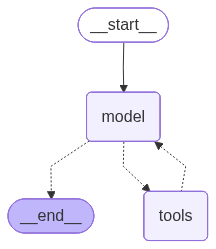

In [14]:
orchestrator_agent = create_agent(
    model=llm_orch,
    tools=[write_research_plan, run_researcher, run_editor, cleanup_files],
    system_prompt=ORCHESTRATOR_PROMPT,
    checkpointer=checkpointer,
    state_schema=DeepAgentState
)

orchestrator_agent

### Example

In [ ]:
from agent.agent_utils import stream_agent_response

# stream_agent_response(orchestrator_agent, "what is a 10-k report", thread_id="thread_002", user_id="user_212")

In [17]:
# #complex financial research 
stream_agent_response(
    orchestrator_agent,
    query=" Do a detailed analysis of Amazon's financial performance in 2023 and 2024",
    thread_id="thread_013",
    user_id="user_133"
)


 Tool called: write_research_plan

 Args: {'thematic_questions': ["What were Amazon's key financial metrics (revenue, net income, EPS) for the full year 2023 and the available quarters of 2024?", "How did Amazon's major business segments (Online Stores, AWS, Advertising, Third-party seller services) perform in 2023 and 2024?", "What were the major drivers of Amazon's profitability and margin expansion in 2023 and 2024, including cost-cutting measures?", 'What are the key growth initiatives and future outlook for Amazon as of late 2024, including AI investments and logistics improvements?', "How does Amazon's financial performance in 2023-2024 compare to its main competitors and the broader retail/cloud market?"]}


ENTRANDO A write_research_plan
state keys: ['messages', 'user_id', 'thread_id']
user_id: user_133
thread_id: thread_013
thematic_questions: ["What were Amazon's key financial metrics (revenue, net income, EPS) for the full year 2023 and the available quarters of 2024?", "Ho